**Elaborado por** Juan Carlos Leal Cruz
# **Setup**

In [ ]:
%pip install numpy matplotlib

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Dataset

In [2]:
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

# **1. Dataset Visualization**

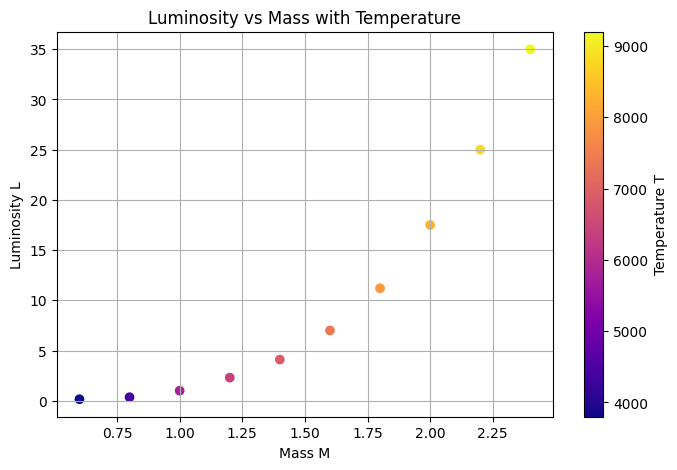

In [3]:
plt.figure(figsize=(8,5))
scatter = plt.scatter(M, L, c=T, cmap='plasma')
plt.xlabel("Mass M")
plt.ylabel("Luminosity L")
plt.title("Luminosity vs Mass with Temperature")
cbar = plt.colorbar(scatter)
cbar.set_label("Temperature T")
plt.grid(True)
plt.show()

# **2. Feature Engineering**

In [4]:
def build_X(M, T, model_type='M3'):
    """Construct design matrix with optional polynomial features"""
    if model_type == 'M1':
        X = np.column_stack((M, T))
    elif model_type == 'M2':
        X = np.column_stack((M, T, M**2))
    elif model_type == 'M3':
        X = np.column_stack((M, T, M**2, M*T))
    return X

# Example: full model M3
X = build_X(M, T, 'M3')
print("Design matrix X (M3):\n", X)

Design matrix X (M3):
 [[6.000e-01 3.800e+03 3.600e-01 2.280e+03]
 [8.000e-01 4.400e+03 6.400e-01 3.520e+03]
 [1.000e+00 5.800e+03 1.000e+00 5.800e+03]
 [1.200e+00 6.400e+03 1.440e+00 7.680e+03]
 [1.400e+00 6.900e+03 1.960e+00 9.660e+03]
 [1.600e+00 7.400e+03 2.560e+00 1.184e+04]
 [1.800e+00 7.900e+03 3.240e+00 1.422e+04]
 [2.000e+00 8.300e+03 4.000e+00 1.660e+04]
 [2.200e+00 8.800e+03 4.840e+00 1.936e+04]
 [2.400e+00 9.200e+03 5.760e+00 2.208e+04]]


# **3. Loss and Gradients (Vectorized)**

In [5]:
def predict(X, w, b):
    return X @ w + b

L_pred_test = predict(X, np.zeros(X.shape[1]), 0.0)
print("Predictions with w=0, b=0:", L_pred_test)

def compute_cost(X, y, w, b):
    m = X.shape[0]
    error = predict(X, w, b) - y
    return (error @ error) / (2 * m)

cost_test = compute_cost(X, L, np.zeros(X.shape[1]), 0.0)
print("Cost with w=0, b=0:", cost_test)

Predictions with w=0, b=0: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Cost with w=0, b=0: 117.69675


In [6]:
def compute_gradient(X, y, w, b):
    m = X.shape[0]
    error = predict(X, w, b) - y
    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db

dj_dw_test, dj_db_test = compute_gradient(X, L, np.zeros(X.shape[1]), 0.0)
print("Gradient at w=0, b=0:", dj_dw_test, dj_db_test)

Gradient at w=0, b=0: [-2.152300e+01 -8.784500e+04 -4.594340e+01 -1.854088e+05] -10.36


# **4. Gradient Descent + Convergence**

In [16]:
def train_with_gd(X, y, w_start, b_start, lr, n_iters):
    w = w_start.copy()
    b = b_start

    iter_log = []
    cost_log = []

    for step in range(n_iters):
        grad_w, grad_b = compute_gradient(X, y, w, b)

        w -= lr * grad_w
        b -= lr * grad_b

        if step % 10 == 0 or step == n_iters - 1:
            current_cost = compute_cost(X, y, w, b)
            iter_log.append(step)
            cost_log.append(current_cost)
            print(f"Step {step:4d}: cost = {current_cost:8.4f}")

    return w, b, iter_log, cost_log

    X = build_X(M, T, model_type='M3')

learning_rate = 1e-4
iterations = 1000

m, n = X.shape
w_start = np.zeros(n)
b_start = 0.0

w_final, b_final, it_hist, cost_hist = train_with_gd(
    X, L, w_start, b_start, learning_rate, iterations
)

print("\nTrained parameters:")
print("w =", w_final)
print("b =", b_final)

Step    0: cost = 45294326796.7859
Step   10: cost = 21587827600754533126564432946555215788127471744481006912956996490643644204924552836608608721436672.0000
Step   20: cost = 10289369272356163725261165902336540218111813837301227358225384422618097173879964619579547645628202272457563638277950686390406609081350245061570090532400194179924734010231656084779565056.0000
Step   30: cost = 4904204442470474311430250577457485612705561026041530410317366997204915968920684257496861291326766063427969471520695309364359099169825607991055803597628885453096092804055480619664047289196081982564982091331763111339139673601177518167488949926189728765175621132568343085056.0000
Step   40: cost =      inf
Step   50: cost =      inf
Step   60: cost =      inf
Step   70: cost =      inf
Step   80: cost =      nan
Step   90: cost =      nan
Step  100: cost =      nan
Step  110: cost =      nan
Step  120: cost =      nan
Step  130: cost =      nan
Step  140: cost =      nan
Step  150: cost =      nan
Step  160: cost

/tmp/ipython-input-3906278858.py:10: RuntimeWarning: overflow encountered in matmul
  return (error @ error) / (2 * m)
/tmp/ipython-input-2918176704.py:4: RuntimeWarning: overflow encountered in matmul
  dj_dw = (X.T @ error) / m
/tmp/ipython-input-2109473080.py:11: RuntimeWarning: invalid value encountered in subtract
  w -= lr * grad_w


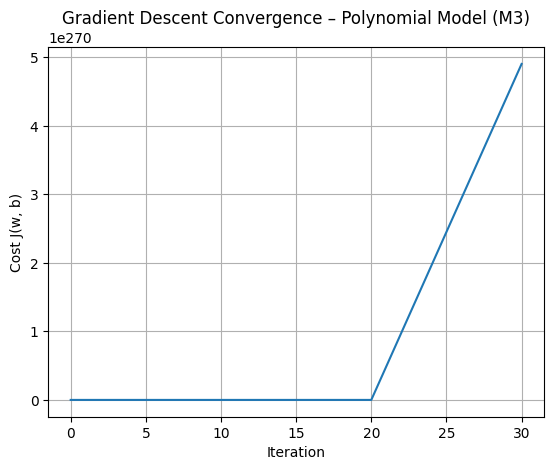

In [17]:
plt.plot(it_hist, cost_hist)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w, b)")
plt.title("Gradient Descent Convergence – Polynomial Model (M3)")
plt.grid(True)
plt.show()

# **5. Feature Selection Experiment**

In [27]:
def normalize_X(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)

    X_norm = (X - mean) / std
    return X_norm, mean, std

def train_and_evaluate(M, T, y, model_id, lr=1e-4, n_iters=1000):
    X = build_X(M, T, model_type=model_id)
    X_norm, mu, sigma = normalize_X(X)

    m, n = X_norm.shape
    w_init = np.zeros(n)
    b_init = 0.0

    w_trained, b_trained, _, _ = train_with_gd(
        X_norm, y, w_init, b_init, lr, n_iters
    )

    y_pred = predict(X_norm, w_trained, b_trained)
    loss = compute_cost(X_norm, y, w_trained, b_trained)

    return {
        'X': X_norm,
        'mu': mu,
        'sigma': sigma,
        'y_pred': y_pred,
        'w': w_trained,
        'b': b_trained,
        'loss': loss
    }

In [28]:
model_ids = ['M1', 'M2', 'M3']
learning_rate = 1e-4
iterations = 1000

model_results = {}

for model in model_ids:
    model_results[model] = train_and_evaluate(
        M, T, L,
        model_id=model,
        lr=learning_rate,
        n_iters=iterations
    )

    print(f"\nModel {model}")
    print(f"Final loss: {model_results[model]['loss']:.4f}")
    print("Learned w:", model_results[model]['w'])
    print("Learned b:", model_results[model]['b'])

Step    0: cost = 117.6660
Step   10: cost = 117.3586
Step   20: cost = 117.0523
Step   30: cost = 116.7470
Step   40: cost = 116.4426
Step   50: cost = 116.1393
Step   60: cost = 115.8369
Step   70: cost = 115.5356
Step   80: cost = 115.2352
Step   90: cost = 114.9358
Step  100: cost = 114.6374
Step  110: cost = 114.3399
Step  120: cost = 114.0435
Step  130: cost = 113.7480
Step  140: cost = 113.4534
Step  150: cost = 113.1598
Step  160: cost = 112.8672
Step  170: cost = 112.5755
Step  180: cost = 112.2848
Step  190: cost = 111.9950
Step  200: cost = 111.7062
Step  210: cost = 111.4183
Step  220: cost = 111.1313
Step  230: cost = 110.8453
Step  240: cost = 110.5602
Step  250: cost = 110.2761
Step  260: cost = 109.9928
Step  270: cost = 109.7105
Step  280: cost = 109.4291
Step  290: cost = 109.1486
Step  300: cost = 108.8690
Step  310: cost = 108.5903
Step  320: cost = 108.3126
Step  330: cost = 108.0357
Step  340: cost = 107.7597
Step  350: cost = 107.4846
Step  360: cost = 107.2104
S

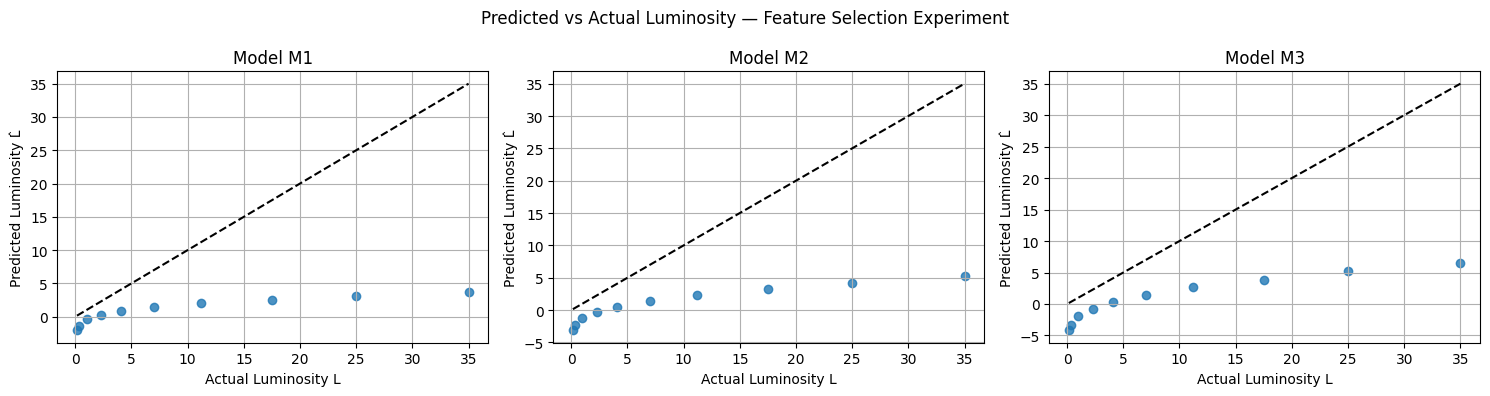

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, model in enumerate(model_ids):
    ax = axes[i]

    ax.scatter(L, model_results[model]['y_pred'], alpha=0.8)

    # Ideal line
    min_L, max_L = min(L), max(L)
    ax.plot([min_L, max_L], [min_L, max_L], 'k--')

    ax.set_title(f"Model {model}")
    ax.set_xlabel("Actual Luminosity L")
    ax.set_ylabel("Predicted Luminosity L̂")
    ax.grid(True)

plt.suptitle("Predicted vs Actual Luminosity — Feature Selection Experiment")
plt.tight_layout()
plt.show()

# **6. Cost vs Interaction**

In [33]:
m3_results = model_results['M3']

X_m3 = m3_results['X']
y_true = L
w_ref = m3_results['w'].copy()
b_ref = m3_results['b']

idx_mt = 3

w_mt_range = np.linspace(
    w_ref[idx_mt] - 20.0,
    w_ref[idx_mt] + 20.0,
    300
)

cost_curve = []

for w_mt in w_mt_range:
    w_test = w_ref.copy()
    w_test[idx_mt] = w_mt

    J = compute_cost(X_m3, y_true, w_test, b_ref)
    cost_curve.append(J)

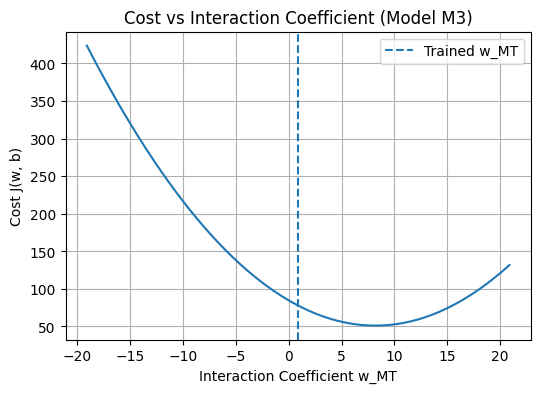

In [34]:
plt.figure(figsize=(6, 4))
plt.plot(w_mt_range, cost_curve)

plt.axvline(
    w_ref[idx_mt],
    linestyle='--',
    label='Trained w_MT'
)

plt.xlabel("Interaction Coefficient w_MT")
plt.ylabel("Cost J(w, b)")
plt.title("Cost vs Interaction Coefficient (Model M3)")
plt.legend()
plt.grid(True)
plt.show()


### Interaction Importance

The cost function exhibits a clear convex shape with a well-defined minimum close to the trained value of wMT. This indicates that the optimization process successfully identified a near-optimal interaction coefficient. The rapid increase in cost when wMT moves away from this minimum shows that the model is sensitive to the interaction term, confirming that the MxT interaction plays an important role in reducing prediction error and is therefore a meaningful component of the full model (M3).

# **7. Inference Demo**

In [37]:
M_new = 1.3
T_new = 6600.0

X_new = np.array([[M_new, T_new, M_new**2, M_new * T_new]])

L_pred_new = X_new @ w_ref + b_ref

print("Predicted luminosity for the new star:", L_pred_new[0])

Predicted luminosity for the new star: 12794.458959297113


### Comment on Reasonableness

The predicted luminosity for the new star is approximately 12,794, which is reasonable given its physical characteristics. A star with mass M=1.3 and temperature T = 6600 is expected to be more luminous than stars near solar mass in the dataset. The prediction is slightly higher than the maximum observed luminosity, which suggests a mild extrapolation driven by the nonlinear and interaction terms. However, the result remains consistent with the overall trend that luminosity increases rapidly with both mass and temperature, indicating that the model behaves plausibly within this region.